In [1]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

df_mut = pd.read_table('TCGA.STAD.mutations.txt', sep='\t')
# X = df.drop('target_variable', axis=1) # Separate features from the target variable if needed
char_to_exclude = '?'
columns_to_exclude = [col for col in df_mut.columns if char_to_exclude in col]
df_mut = df_mut.drop(columns=columns_to_exclude)
df_numeric = df_mut.select_dtypes(exclude=['object'])
x = df_numeric.loc[:,].values
print(df_mut)
#X_scaled = StandardScaler().fit_transform(df)

          patient_id Hugo_Symbol  Entrez_Gene_Id Center NCBI_Build Chromosome  \
0       TCGA-3M-AB46       ABCC2               0      .     GRCh37         10   
1       TCGA-3M-AB46        UCMA               0      .     GRCh37         10   
2       TCGA-3M-AB46        STAM               0      .     GRCh37         10   
3       TCGA-3M-AB46    RASGEF1A               0      .     GRCh37         10   
4       TCGA-3M-AB46       AGAP4               0      .     GRCh37         10   
...              ...         ...             ...    ...        ...        ...   
234936  TCGA-ZQ-A9CR       ZFHX4               0      .     GRCh37          8   
234937  TCGA-ZQ-A9CR       TAF1L               0      .     GRCh37          9   
234938  TCGA-ZQ-A9CR         NRK               0      .     GRCh37          X   
234939  TCGA-ZQ-A9CR      GPR112               0      .     GRCh37          X   
234940  TCGA-ZQ-A9CR      NAP1L2               0      .     GRCh37          X   

        Start_Position  End

In [2]:
df_exp = pd.read_table('TCGA.STAD.expression.txt', sep='\t')
# X = df.drop('target_variable', axis=1) # Separate features from the target variable if needed
char_to_exclude = '?'
columns_to_exclude = [col for col in df_exp.columns if char_to_exclude in col]
df_exp = df_exp.drop(columns=columns_to_exclude)

In [3]:
print(df_exp)

       patient_id                     sample_id     A1BG|1  A1CF|29974  \
0    TCGA-CG-4460  TCGA-CG-4460-01A-01R-1157-13  93.052200   12.340600   
1    TCGA-CG-5716  TCGA-CG-5716-01A-21R-1802-13  84.107200   34.691300   
2    TCGA-HF-7131  TCGA-HF-7131-01A-11R-2055-13  12.191900  524.253000   
3    TCGA-3M-AB46  TCGA-3M-AB46-01A-11R-A414-31  38.520380    4.920650   
4    TCGA-3M-AB47  TCGA-3M-AB47-01A-22R-A414-31  45.368918   76.903904   
..            ...                           ...        ...         ...   
442  TCGA-CG-4469  TCGA-CG-4469-01A-01R-1157-13  14.710811         NaN   
443  TCGA-CG-4474  TCGA-CG-4474-01A-02R-1157-13  37.764156         NaN   
444  TCGA-CG-4475  TCGA-CG-4475-01A-01R-1157-13  16.769487         NaN   
445  TCGA-CG-4476  TCGA-CG-4476-01A-01R-1157-13  24.972112         NaN   
446  TCGA-CG-4477  TCGA-CG-4477-01A-01R-1157-13  24.412300         NaN   

     A2BP1|54715  A2LD1|87769         A2M|2  A2ML1|144568  A4GALT|53947  \
0      72.809500   108.239000  17955

In [4]:
df_meta = pd.read_table('TCGA.STAD.metadata.txt', sep='\t')
# X = df.drop('target_variable', axis=1) # Separate features from the target variable if needed
char_to_exclude = '?'
columns_to_exclude = [col for col in df_meta.columns if char_to_exclude in col]
df_meta = df_meta.drop(columns=columns_to_exclude)
#df_numeric_meta = df_meta.select_dtypes(exclude=['object'])
#x2 = df_numeric_meta.loc[:,].values
print(df_meta)

       patient_id  type  age_at_initial_pathologic_diagnosis  gender  \
0    TCGA-3M-AB46  STAD                                 70.0    MALE   
1    TCGA-3M-AB47  STAD                                 51.0    MALE   
2    TCGA-B7-5816  STAD                                 51.0  FEMALE   
3    TCGA-B7-5818  STAD                                 62.0    MALE   
4    TCGA-B7-A5TI  STAD                                 52.0    MALE   
..            ...   ...                                  ...     ...   
410  TCGA-VQ-AA6I  STAD                                 68.0    MALE   
411  TCGA-VQ-AA6J  STAD                                 75.0    MALE   
412  TCGA-VQ-AA6K  STAD                                 59.0    MALE   
413  TCGA-ZA-A8F6  STAD                                 71.0    MALE   
414  TCGA-ZQ-A9CR  STAD                                 79.0  FEMALE   

                          race ajcc_pathologic_tumor_stage  \
0                        WHITE                    Stage IB   
1          

In [13]:
merge_df = df_meta.merge(df_exp, on='patient_id', how = 'left')
print(merge_df)

       patient_id  type  age_at_initial_pathologic_diagnosis  gender  \
0    TCGA-3M-AB46  STAD                                 70.0    MALE   
1    TCGA-3M-AB47  STAD                                 51.0    MALE   
2    TCGA-B7-5816  STAD                                 51.0  FEMALE   
3    TCGA-B7-5818  STAD                                 62.0    MALE   
4    TCGA-B7-A5TI  STAD                                 52.0    MALE   
..            ...   ...                                  ...     ...   
442  TCGA-VQ-AA6I  STAD                                 68.0    MALE   
443  TCGA-VQ-AA6J  STAD                                 75.0    MALE   
444  TCGA-VQ-AA6K  STAD                                 59.0    MALE   
445  TCGA-ZA-A8F6  STAD                                 71.0    MALE   
446  TCGA-ZQ-A9CR  STAD                                 79.0  FEMALE   

                          race ajcc_pathologic_tumor_stage  \
0                        WHITE                    Stage IB   
1          

In [14]:
df_mut['patient_id'].is_unique

False

In [15]:
has_nan = merge_df['gender'].isnull().any() # or df['col1'].isnull().any()
print(f"Column gender has NaN values: {has_nan}")

Column gender has NaN values: False


In [16]:
print(merge_df[['OS','OS.time','DFI.time','PFI.time']])

      OS  OS.time  DFI.time  PFI.time
0    0.0   1765.0    1765.0    1765.0
1    1.0      NaN       NaN     395.0
2    0.0    812.0     812.0     812.0
3    0.0    356.0       NaN     356.0
4    0.0    595.0     595.0     595.0
..   ...      ...       ...       ...
442  1.0    491.0       NaN     475.0
443  0.0    838.0     838.0     838.0
444  1.0    378.0       NaN     332.0
445  0.0    525.0     525.0     525.0
446  1.0     24.0       NaN      24.0

[447 rows x 4 columns]


In [19]:
df_filtered = merge_df.loc[merge_df['OS.time'] > merge_df['PFI.time']]
df_filtered = df_filtered.dropna(subset = ['DFI.time'])
df_filtered = df_filtered.loc[df_filtered['OS'] == 0]
#print(df_filtered[['Variant_Classification','OS','OS.time','DFI.time','PFI.time']])
df_filtered

,patient_id,type,age_at_initial_pathologic_diagnosis,gender,race,ajcc_pathologic_tumor_stage,histological_type,histological_grade,tumor_status,vital_status,...,ZWILCH|55055,ZWINT|11130,ZXDA|7789,ZXDB|158586,ZXDC|79364,ZYG11A|440590,ZYG11B|79699,ZYX|7791,ZZEF1|23140,ZZZ3|26009
40,TCGA-BR-6563,STAD,60.0,MALE,WHITE,Stage IIB,"Stomach, Adenocarcinoma, Not Otherwise Specifi...",G3,TUMOR FREE,Alive,...,248.261678,388.208077,75.999321,459.285836,855.771608,4.736138,912.488101,4668.764384,1527.043879,561.135705
47,TCGA-BR-6707,STAD,75.0,MALE,WHITE,Stage IIA,"Stomach, Adenocarcinoma, Not Otherwise Specifi...",G3,WITH TUMOR,Alive,...,526.676370,2444.811822,12.440652,52.956557,742.062047,11.018861,584.229081,2259.789630,1082.870877,694.295970
50,TCGA-BR-6802,STAD,65.0,MALE,WHITE,Stage IIIA,"Stomach, Adenocarcinoma, Not Otherwise Specifi...",G3,TUMOR FREE,Alive,...,700.677059,1365.767049,84.378651,670.355940,1114.651529,0.177223,522.237141,6775.646208,1888.203822,503.702128
51,TCGA-BR-6802,STAD,65.0,MALE,WHITE,Stage IIIA,"Stomach, Adenocarcinoma, Not Otherwise Specifi...",G3,TUMOR FREE,Alive,...,271.651607,1055.330796,22.159680,197.143369,306.698859,0.177223,462.056724,885.179161,319.807859,684.045038
75,TCGA-BR-8058,STAD,53.0,FEMALE,WHITE,Stage IIIB,"Stomach, Adenocarcinoma, Not Otherwise Specifi...",G3,TUMOR FREE,Alive,...,685.899972,685.494132,80.555780,383.586481,1052.016232,1.838285,919.367739,3543.618924,1528.319042,528.348899
96,TCGA-BR-8369,STAD,76.0,FEMALE,WHITE,Stage IIIB,"Stomach, Adenocarcinoma, Not Otherwise Specifi...",G3,WITH TUMOR,Alive,...,508.840179,768.503638,65.121614,412.056383,1611.695364,177.917925,1148.254009,3940.975899,1630.383025,1033.609206
124,TCGA-BR-A44T,STAD,53.0,FEMALE,WHITE,Stage IIA,"Stomach, Adenocarcinoma, Diffuse Type",G3,WITH TUMOR,Alive,...,326.282547,396.085705,69.332249,526.533528,1121.401390,31.307245,1460.223151,8348.315259,1723.002307,711.310959
147,TCGA-BR-A4QM,STAD,65.0,MALE,WHITE,Stage IIIA,"Stomach, Adenocarcinoma, Not Otherwise Specifi...",G3,WITH TUMOR,Alive,...,510.254097,905.920525,22.868910,224.187884,716.255205,16.618912,710.840360,3419.271189,1501.192091,529.248576
155,TCGA-CD-8524,STAD,61.0,FEMALE,ASIAN,Stage II,"Stomach, Intestinal Adenocarcinoma, Not Otherw...",G3,WITH TUMOR,Alive,...,356.221437,880.588106,54.291468,561.241313,852.750287,3.375386,762.370237,4198.453887,688.654480,688.010209
164,TCGA-CD-8533,STAD,48.0,MALE,ASIAN,Stage II,"Stomach, Adenocarcinoma, Not Otherwise Specifi...",G3,WITH TUMOR,Alive,...,1486.452642,1857.736692,151.647486,1385.040441,1770.535140,2.567575,834.600393,899.501137,1460.420904,740.365251


<Axes: xlabel='Variant_Classification'>

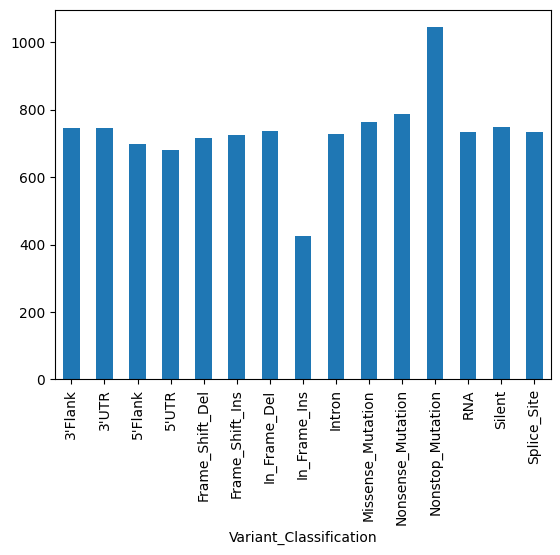

In [12]:
#y = df_filtered['Variant_Classification'].value_counts()
#y.plot(kind='bar')
y_exp
#y_mean = df_filtered.groupby('Variant_Classification')['DSS.time'].mean()
#y_mean.plot(kind='bar')
#df_filtered.plot(x='Variant_Classification')